# Plot model and satellite SIC

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime
import boto3
import s3fs

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36135")
client

<Client: 'tcp://127.0.0.1:36135' processes=8 threads=32, memory=123.95 GiB>

### Open satellite data

In [3]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

In [4]:
sic_ancillary =  xr.open_dataset(sic_files[0])

In [24]:
# sic_ds = xr.open_dataset(sic_files[1])
sic_ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20140915_F17_v05r00.nc')

In [25]:
lat_min = 68
lat_max = 78
lon_min = -158
lon_max = -120

In [26]:
sat_subset_mask = sic_ds.where(
    (sic_ancillary.latitude >= lat_min) & (sic_ancillary.latitude <= lat_max) &
    (sic_ancillary.longitude >= lon_min) & (sic_ancillary.longitude <= lon_max)
)

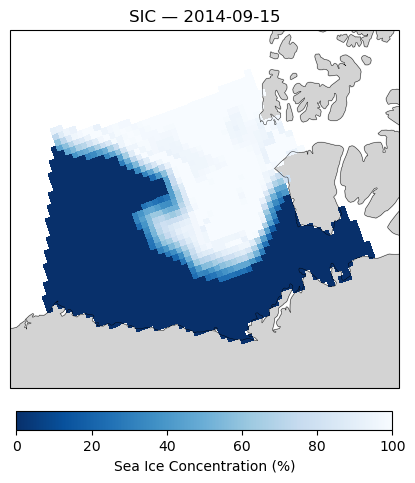

In [27]:
# Define NSIDC stereographic projection (matching dataset grid)
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')

# Transformer from NSIDC grid to geographic coordinates
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

sic = sat_subset_mask.cdr_seaice_conc*100

# Create 2D lat/lon fields from x/y coordinates
x = sic["x"].values
y = sic["y"].values
xx, yy = np.meshgrid(x, y)

lon, lat = transformer.transform(xx, yy)

# Add lat/lon to DataArray (if not already present)
sic = sic.assign_coords(lon=(("y", "x"), lon), lat=(("y", "x"), lat))

# Create figure — 4x2 grid (you can fill multiple time steps later)
fig, ax = plt.subplots(1, 1, figsize=(5, 5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})

# Plot the single SIC field (first timestep)
ax.set_extent([-161, -120, 68, 80], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=1, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

# Plot SIC data
pcm = ax.pcolormesh(
    sic.lon, sic.lat, sic.isel(time=0),
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

# Add colorbar
cbar = plt.colorbar(pcm, ax=ax, orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_label("Sea Ice Concentration (%)")

ax.set_title(f"SIC — {sic.time.dt.strftime('%Y-%m-%d').values[0]}")

plt.tight_layout()
plt.show()

### Open model data

In [13]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()
    return credentials

In [14]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, aws_credentials):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [15]:
# get creds
aws_credentials = get_aws_credentials(profile_name='sassie')

In [34]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
sic_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', aws_credentials)

In [35]:
# select beaufort sea box
sic_beaufort_da = (sic_model_ds.SIarea*100).where(
    (sic_model_ds.YC >= lat_min) & (sic_model_ds.YC <= lat_max) &
    (sic_model_ds.XC >= lon_min) & (sic_model_ds.XC <= lon_max)
)

In [36]:
# select specific day
sic_beaufort_da_tmp = sic_beaufort_da.sel(time='2014-09-15')

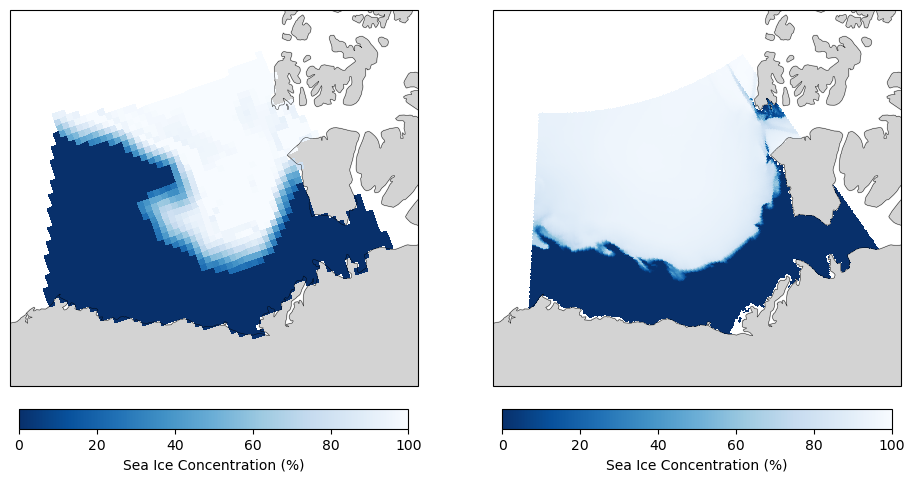

In [40]:
# Define NSIDC stereographic projection (matching dataset grid)
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')

# Transformer from NSIDC grid to geographic coordinates
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

sic = sat_subset_mask.cdr_seaice_conc*100

# Create 2D lat/lon fields from x/y coordinates
x = sic["x"].values
y = sic["y"].values
xx, yy = np.meshgrid(x, y)

lon, lat = transformer.transform(xx, yy)

# Add lat/lon to DataArray (if not already present)
sic = sic.assign_coords(lon=(("y", "x"), lon), lat=(("y", "x"), lat))

# Create figure — 4x2 grid (you can fill multiple time steps later)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})

# Plot the single SIC field (first timestep)
ax1.set_extent([-161, -120, 68, 80], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, zorder=1, color='lightgray')
ax1.add_feature(cfeature.COASTLINE, linewidth=0.3)

ax2.set_extent([-161, -120, 68, 80], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, zorder=1, color='lightgray')
ax2.add_feature(cfeature.COASTLINE, linewidth=0.3)

# Plot satellite SIC data
pcm = ax1.pcolormesh(
    sic.lon, sic.lat, sic.isel(time=0),
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

# Plot model SIC data
pcm1 = ax2.pcolormesh(
    sic_beaufort_da.isel(time=0).XC, sic_beaufort_da.isel(time=0).YC, sic_beaufort_da.isel(time=0),
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

pcm2 = ax2.pcolormesh(
    sic_beaufort_da_tmp.XC, sic_beaufort_da_tmp.YC, sic_beaufort_da_tmp.isel(time=0),
    transform=ccrs.PlateCarree(),
    cmap='Blues_r', vmin=0, vmax=100
)

# Add colorbar
cbar = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_label("Sea Ice Concentration (%)")

cbar = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', shrink=0.8, pad=0.05)
cbar.set_label("Sea Ice Concentration (%)")

ax.set_title(f"SIC — {sic.time.dt.strftime('%Y-%m-%d').values[0]}")

plt.tight_layout()
plt.show()

In [58]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")
grid_area = HH_grid.rAc.isel(i=slice(510,850),j=slice(0,450))

In [50]:
# select the time range
sic_model_da = sic_beaufort_da.sel(time=slice("2014", "2020")).isel(i=slice(510,850),j=slice(0,450))

In [52]:
# compute monthly means
sic_da_monthly = sic_model_da.resample(time="ME", label="right", closed="right").mean()
sic_da_monthly["time"] = [pd.Timestamp(pd.to_datetime(t)).replace(day=15) for t in sic_da_monthly.time.values]

# average spatially (over i and j)
sic_monthly_mean = sic_da_monthly.mean(dim=("i", "j")).load()
sic_monthly_std = sic_da_monthly.std(dim=("i", "j")).load()

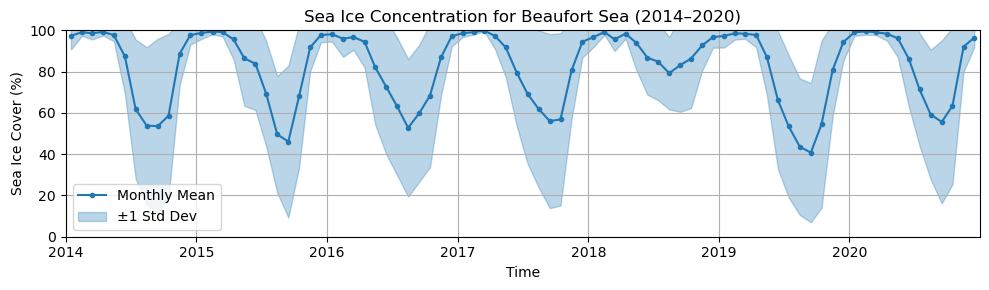

In [53]:
# plot mean and std
plt.figure(figsize=(10, 3))
plt.plot(sic_monthly_mean.time, sic_monthly_mean, marker='.', label="Monthly Mean", color="C0")
plt.fill_between(
    sic_monthly_mean.time,
    sic_monthly_mean - sic_monthly_std,
    sic_monthly_mean + sic_monthly_std,
    color="C0",
    alpha=0.3,
    label="±1 Std Dev"
)
plt.title("Sea Ice Concentration for Beaufort Sea (2014–2020)")
plt.xlabel("Time")
plt.ylabel("Sea Ice Cover (%)")
plt.ylim(0,100)
plt.xlim(np.datetime64('2014-01-01'),np.datetime64('2020-12-31'))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()